In [1]:
!pip install -q transformers datasets evaluate accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.0 MB/s eta 0:00:00:00:01:01
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cud

In [5]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from datasets import load_dataset
from transformers import ViTImageProcessor, ViTForImageClassification
from transformers import TrainingArguments, Trainer
import evaluate

In [33]:
DATASET_PATH = "/kaggle/input/datasets/ananthu017/emotion-detection-fer"

dataset = load_dataset("imagefolder", data_dir=DATASET_PATH)

print(dataset)
print(dataset["train"].features)

Resolving data files:   0%|          | 0/28709 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/7178 [00:00<?, ?it/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 28709
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 7178
    })
})
{'image': Image(mode=None, decode=True), 'label': ClassLabel(names=['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised'])}


In [34]:
labels = dataset["train"].features["label"].names
num_labels = len(labels)

id2label = {i: label for i, label in enumerate(labels)}
label2id = {label: i for i, label in enumerate(labels)}

print(labels)
print(num_labels)

['angry', 'disgusted', 'fearful', 'happy', 'neutral', 'sad', 'surprised']
7


In [35]:
model_name = "google/vit-base-patch16-224-in21k"
processor = ViTImageProcessor.from_pretrained(model_name)

In [36]:
def transform(batch):
    images = [img.convert("RGB") for img in batch["image"]]
    inputs = processor(images, return_tensors="pt")
    batch["pixel_values"] = inputs["pixel_values"]
    batch["labels"] = batch["label"]
    return batch

dataset = dataset.with_transform(transform)

In [37]:
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id
)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [38]:
accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels_true = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=predictions, references=labels_true)

In [39]:
def collate_fn(batch):
    return {
        "pixel_values": torch.stack([item["pixel_values"] for item in batch]),
        "labels": torch.tensor([item["labels"] for item in batch])
    }

In [46]:
training_args = TrainingArguments(
    output_dir="/kaggle/working/vit-emotion-model",
    eval_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    per_device_eval_batch_size=64,
    num_train_epochs=4,
    weight_decay=0.01,
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    report_to="none",
    remove_unused_columns=False
)

In [47]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset["train"],
    eval_dataset=dataset["test"],
    data_collator=collate_fn,
    compute_metrics=compute_metrics
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,1.109751,1.066293,0.627612
2,0.955995,0.990645,0.647534
3,0.867289,0.965111,0.658261
4,0.829951,0.947101,0.665366


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=900, training_loss=0.9773956637912327, metrics={'train_runtime': 3079.4665, 'train_samples_per_second': 37.291, 'train_steps_per_second': 0.292, 'total_flos': 8.899268908172009e+18, 'train_loss': 0.9773956637912327, 'epoch': 4.0})

In [48]:
trainer.evaluate()

{'eval_loss': 0.9471012949943542,
 'eval_accuracy': 0.6653663973251602,
 'eval_runtime': 73.1063,
 'eval_samples_per_second': 98.186,
 'eval_steps_per_second': 0.78,
 'epoch': 4.0}

In [49]:
def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")

    inputs = processor(image, return_tensors="pt").to(model.device)

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        pred_id = torch.argmax(probs, dim=1).item()
        confidence = probs[0][pred_id].item()

    pred_label = id2label[pred_id]

    plt.imshow(image, cmap="gray")
    plt.axis("off")
    plt.title(f"Prediction: {pred_label} | Confidence: {confidence:.2f}")
    plt.show()

    return pred_label, confidence

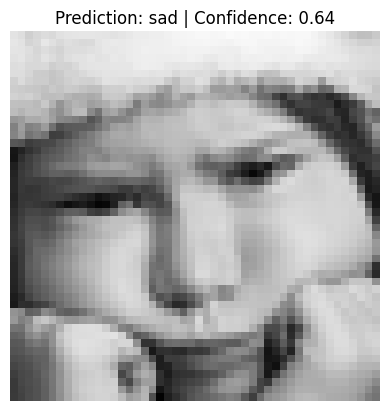

('sad', 0.6426312923431396)

In [50]:
test_folder = os.path.join(DATASET_PATH, "test", labels[0])
test_image = os.path.join(test_folder, os.listdir(test_folder)[0])

predict_image(test_image)